Jalur Python: C:\anaconda3\envs\metodepotensial\python.exe
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.
Variabel yang terdeteksi di file: ['free_air']
Data 'height' tidak ada. Menggunakan asumsi 500m untuk demo.


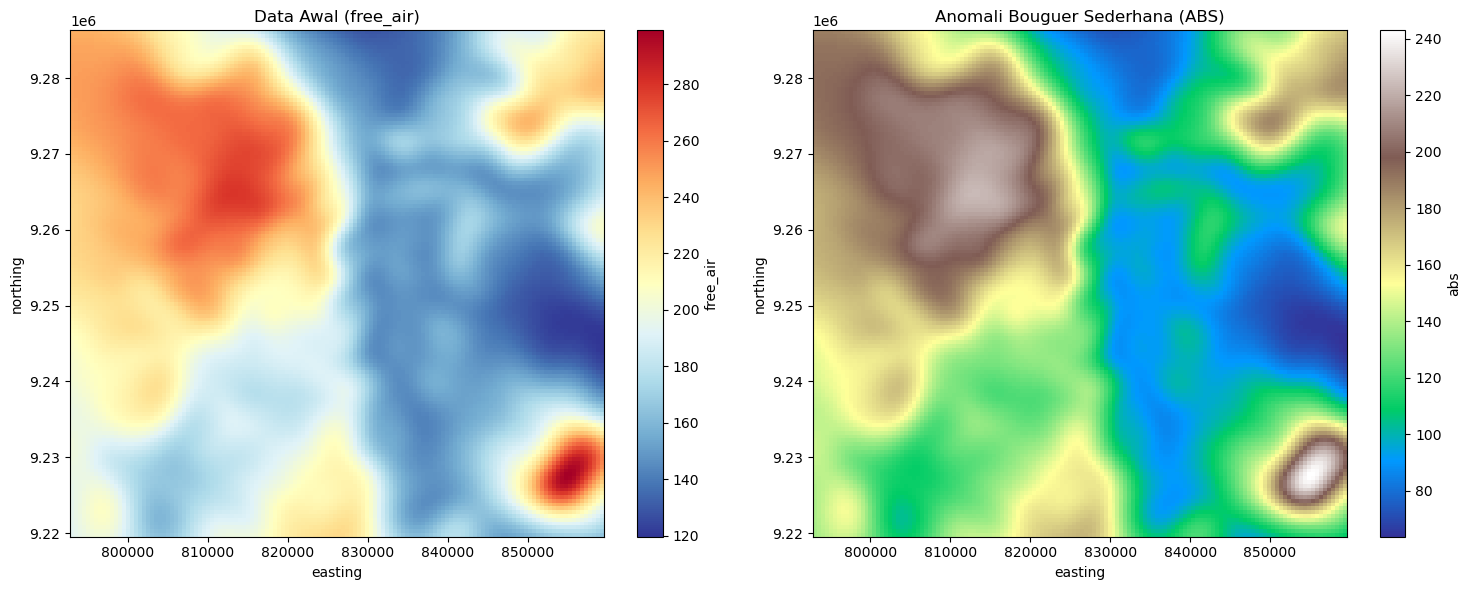

✅ BERHASIL! Peta ABS sudah muncul dan file disimpan.


In [1]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import xarray as xr
import harmonica as hm
import matplotlib.pyplot as plt
import os

# 1. Load Grid yang tadi berhasil dibuat
path_grid = "D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/grid_tampomas_fa.nc"

if not os.path.exists(path_grid):
    print("File grid tidak ditemukan! Cek apakah tahap gridding benar-benar sukses.")
else:
    grid = xr.open_dataset(path_grid)

    # --- SOLUSI ERROR ATTRIBUTE ---
    # Mengecek apa nama variabel di dalam file secara otomatis
    var_list = list(grid.data_vars)
    print(f"Variabel yang terdeteksi di file: {var_list}")
    
    # Pilih variabel pertama (biasanya 'free_air' atau 'disturbance')
    data_key = var_list[0] 
    # ------------------------------

    # 2. Parameter Fisika
    rho_kerak = 2670  # kg/m^3

    # 3. Data Elevasi (h)
    # Jika grid belum punya data height, kita pakai asumsi agar tidak error lagi
    if 'height' in grid.data_vars:
        h = grid.height
    else:
        print("Data 'height' tidak ada. Menggunakan asumsi 500m untuk demo.")
        h = 500

    # 4. Hitung Koreksi Bouguer Sederhana (CB)
    grid["bouguer_correction"] = 0.04193 * (rho_kerak / 1000) * h

    # 5. Hitung Anomali Bouguer Sederhana (ABS)
    # Menggunakan 'data_key' agar tidak terjadi AttributeError lagi
    grid["abs"] = grid[data_key] - grid.bouguer_correction

    # 6. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    grid[data_key].plot(ax=ax1, cmap="RdYlBu_r")
    ax1.set_title(f"Data Awal ({data_key})")

    grid.abs.plot(ax=ax2, cmap="terrain")
    ax2.set_title("Anomali Bouguer Sederhana (ABS)")

    plt.tight_layout()
    plt.show()

    # 7. Simpan Hasil Akhir
    grid.to_netcdf("D:/semester_6/Metode_Potensial/Metode-Potensial/data/proses/tampomas_abs_final.nc")
    print("✅ BERHASIL! Peta ABS sudah muncul dan file disimpan.")
